## 生僻字 / 公式图片 LLM 识别

- **wangzhu** 目录：处理 `.png` 文件（哈希命名，行内嵌入的生僻字占位图）
- **liangzhu** 目录：处理 `.svg` 文件（POTRACE 矢量字形，行内嵌入的生僻字/公式）

输出到 `importData/output/image_analysis.jsonl`，支持断点续跑。

In [2]:
# ============================================================
# Cell 1 — 配置（按实际情况填写）
# ============================================================
import os

BASE_URL = "http://10.128.202.100:3010/v1"   # 自定义 API 地址
API_KEY  = os.getenv("SEU_API_KEY")

# 参与识别的模型列表（均须支持视觉输入）
# 多模型时：每张图各模型独立识别，记录是否一致，不一致时取多数票
MODELS = [
    "kimi-k2.5",
    "qwen3.5-35b-a3b",
    "qwen3-vl-plus",
]

# 图片目录（相对于 notebook 所在的项目根目录）
WANGZHU_DIR  = r"knowledgeBase\wangzhu_unzip\OEBPS\images"   # 处理 .png
LIANGZHU_DIR = r"knowledgeBase\liangzhu_unzip\OEBPS\Images"  # 处理 .svg

# 输出文件
OUTPUT_JSONL = r"importData/output/image_analysis.jsonl"

# 并发线程数（视 API 限速调整，多模型时每张图的调用量 = len(MODELS)）
MAX_WORKERS = 4

# SVG 渲染分辨率放大倍数（POTRACE 原始尺寸仅 32-42pt，需大幅放大）
SVG_SCALE = 12

In [3]:
# ============================================================
# Cell 2 — 导入 & 工具函数
# ============================================================

import io
import json
import base64
import re
import xml.etree.ElementTree as ET
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

from openai import OpenAI
from tqdm import tqdm
from PIL import Image, ImageEnhance, ImageFilter
from svglib.svglib import svg2rlg
from reportlab.graphics import renderPM


# ── MathJax SVG 公式直接提取（无需 LLM）──────────────────────
def extract_formula_from_svg(svg_path: str) -> dict | None:
    """若 SVG 含 <desc> 标签（MathJax 公式），直接提取 LaTeX，100% 准确。"""
    try:
        tree = ET.parse(svg_path)
        root = tree.getroot()
        ns = {"svg": "http://www.w3.org/2000/svg"}
        desc = root.find(".//svg:desc", ns) or root.find(".//desc")
        if desc is not None and desc.text:
            return {"type": "formula", "result": desc.text.strip()}
    except Exception:
        pass
    return None


# ── 图片预处理：渲染/读取 → 增强 → base64 ───────────────────
def prepare_b64(source, scale: int = SVG_SCALE) -> str:
    """
    source 为 SVG 路径时：高分辨率渲染 + 增强。
    source 为 PNG 路径时：放大小图 + 增强。
    返回 base64 字符串。
    """
    path = Path(source)

    if path.suffix.lower() == ".svg":
        drawing = svg2rlg(str(path))
        if drawing is None:
            raise ValueError(f"svglib 无法解析: {path}")
        drawing.width  *= scale
        drawing.height *= scale
        drawing.transform = (scale, 0, 0, scale, 0, 0)
        buf = io.BytesIO()
        renderPM.drawToFile(drawing, buf, fmt="PNG")
        buf.seek(0)
        img = Image.open(buf).convert("RGBA")
        bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        img = bg.convert("RGB")
    else:
        img = Image.open(path).convert("RGB")
        min_side = min(img.width, img.height)
        if min_side < 256:
            ratio = 256 / min_side
            img = img.resize(
                (int(img.width * ratio), int(img.height * ratio)),
                Image.LANCZOS,
            )

    # 加白色边距 + 对比度增强 + 锐化
    pad = max(img.width, img.height) // 4
    canvas = Image.new("RGB", (img.width + 2*pad, img.height + 2*pad), (255, 255, 255))
    canvas.paste(img, (pad, pad))
    canvas = ImageEnhance.Contrast(canvas).enhance(1.5)
    canvas = canvas.filter(ImageFilter.SHARPEN)

    buf = io.BytesIO()
    canvas.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")


# ── 单次 LLM 识别 ────────────────────────────────────────────
PROMPT = ('''
    # Role
    你是一台高精度的古籍数字化与学术符号分析仪。擅长处理模糊、异体字及复杂的数学物理公式。

    # Task
    分析上传图片中的目标对象（汉字或公式），严格按照以下逻辑进行识别并输出 JSON。

    # Rules
    1. **生僻汉字识别 (rare_char)**:
    - **分拆逻辑**: 采用“由外向内、由上至下”的拆解顺序。
    - **IDS 规范**: 必须使用标准 IDS 描述符（⿰, ⿱, ⿲, ⿳, ⿴, ⿵, ⿶, ⿷, ⿸, ⿹, ⿺, ⿻）。
    - **字形推测**: 若部件无法识别，请用其基本笔画形状描述。

    2. **公式与符号识别 (formula)**:
    - **LaTeX 优先**: 复杂的行间或正文公式统一使用标准 LaTeX 格式（不含 $ 符号）。
    - **Unicode 备选**: 单个特殊符号或极简公式若无 LaTeX 必要，可使用 Unicode。
    - **算式完整性**: 确保指数 (^)、下标 (_)、分式 (\frac) 等语法完全准确。

    3. **输出约束**:
    - 禁止任何自然语言解释、开场白或结尾。
    - 仅输出一个合法的 JSON 对象。
    - 若图中同时存在两者，优先识别视觉中心的主要对象。

    # Examples
    - 输入（生僻字）：[图片：水旁加个龙] -> {"type":"rare_char","result":"⿰氵龙"}
    - 输入（公式）：[图片：E=mc^2] -> {"type":"formula","result":"E=mc^2"}
    请开始分析：
'''
)


def analyze_image(client: OpenAI, b64: str, model: str) -> dict:
    """用指定模型调用一次 Vision API，返回 {type, result}。"""
    try:
        resp = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": [
                {"type": "text", "text": PROMPT},
                {"type": "image_url", "image_url": {
                    "url": f"data:image/png;base64,{b64}", "detail": "high"}},
            ]}],
            max_tokens=128,
            temperature=0,
        )
        raw = resp.choices[0].message.content.strip()
        m = re.search(r"\{.*\}", raw, re.DOTALL)
        if m:
            return json.loads(m.group())
        return {"type": "unknown", "result": raw}
    except Exception as e:
        return {"type": "error", "result": str(e)}


def analyze_multi_models(client: OpenAI, b64: str,
                         models: list[str] = MODELS) -> dict:
    """
    并发调用 models 中的每个模型，汇总结果。

    返回字段说明：
      model_results : {model_name: {type, result}, ...}  每个模型的原始结果
      agree         : bool  所有模型的 result 是否完全一致
      type          : str   最终类型（多数票；平局取第一个模型）
      result        : str   最终结果（同上）
    """
    # 并发请求各模型（线程数 = 模型数，通常很少）
    model_results: dict[str, dict] = {}
    with ThreadPoolExecutor(max_workers=len(models)) as ex:
        future_to_model = {ex.submit(analyze_image, client, b64, m): m for m in models}
        for future in as_completed(future_to_model):
            model_results[future_to_model[future]] = future.result()

    # 统计各模型的 result 字段
    from collections import Counter
    result_values = [model_results[m].get("result", "") for m in models]
    total = len(models)
    counter = Counter(result_values)

    # 多数票 result 及其得票数（平局时 most_common 保留插入顺序，即 MODELS 靠前的优先）
    vote, vote_count = counter.most_common(1)[0]

    # 量化一致性
    # consensus      : "vote_count/total" 字符串，如 "2/3"
    # consensus_ratio: 浮点数，如 0.67（保留 2 位小数）
    # agree          : bool，仅当全部一致时为 True
    consensus       = f"{vote_count}/{total}"
    consensus_ratio = round(vote_count / total, 2)
    agree           = vote_count == total

    # 取多数票对应的第一个模型的完整返回（含 type）
    winner_model = next(m for m in models
                        if model_results[m].get("result", "") == vote)
    final = model_results[winner_model]

    return {
        "type": final.get("type", "unknown"),
        "result": vote,
        "agree": agree,
        "consensus": consensus,
        "consensus_ratio": consensus_ratio,
        "model_results": {m: model_results[m] for m in models},
    }

print("工具函数加载完成")

工具函数加载完成


测试 SVG: D:\postgraduate_study\graduation_thesis\llm_rag\myArAppRag\knowledgeBase\liangzhu_unzip\OEBPS\Images\image_379.svg


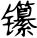

最终结果: [rare_char] ⿰钅⿱莫系  (✗ 1/3 部分一致 (33%))
各模型明细:
  kimi-k2.5: [rare_char] ⿰钅⿱莫系
  qwen3.5-35b-a3b: [rare_char] ⿰釒⿱罒⿱言糸  ← 少数派
  qwen3-vl-plus: [rare_char] ⿰金賁  ← 少数派

测试 PNG: D:\postgraduate_study\graduation_thesis\llm_rag\myArAppRag\knowledgeBase\wangzhu_unzip\OEBPS\images\lwlyypspxb7ddp5gwu.png


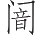

最终结果: [rare_char] ⿵门音  (✗ 2/3 部分一致 (67%))
各模型明细:
  kimi-k2.5: [rare_char] ⿵门音
  qwen3.5-35b-a3b: [rare_char] ⿵门音
  qwen3-vl-plus: [rare_char] ⿵門音  ← 少数派


In [11]:
# ============================================================
# Cell 3 — 快速单图测试
# ============================================================
import random
from IPython.display import display, Image as IPImage, SVG

client = OpenAI(api_key=API_KEY, base_url=BASE_URL)


def _print_multi_result(result: dict):
    """格式化输出多模型结果。"""
    consensus = result.get("consensus", "—")
    ratio     = result.get("consensus_ratio", None)
    if ratio is not None:
        pct = f"{ratio:.0%}"
        agree_tag = f"✓ {consensus} 全部一致" if result["agree"] else f"✗ {consensus} 部分一致 ({pct})"
    else:
        agree_tag = "xml直接提取"
    print(f"最终结果: [{result['type']}] {result['result']}  ({agree_tag})")
    if result.get("model_results"):
        print("各模型明细:")
        for model, r in result["model_results"].items():
            flag = "" if r.get("result") == result["result"] else "  ← 少数派"
            print(f"  {model}: [{r.get('type')}] {r.get('result')}{flag}")


# ---------- 随机取一个 SVG 测试 --------------------------------
svg_list = list(Path(LIANGZHU_DIR).glob("*.svg"))
if svg_list:
    test_svg = random.choice(svg_list)
    print(f"测试 SVG: {test_svg.resolve()}")
    display(SVG(filename=str(test_svg)))

    formula = extract_formula_from_svg(str(test_svg))
    if formula:
        print("直接提取公式（无需 LLM）:", formula)
    else:
        _print_multi_result(analyze_multi_models(client, prepare_b64(test_svg)))

# ---------- 随机取一个 PNG 测试 --------------------------------
png_list = [p for p in Path(WANGZHU_DIR).glob("*.png") if p.name != "img-placeholder.png"]
if png_list:
    test_png = random.choice(png_list)
    print(f"\n测试 PNG: {test_png.resolve()}")
    display(IPImage(filename=str(test_png)))
    _print_multi_result(analyze_multi_models(client, prepare_b64(test_png)))

In [ ]:
# ============================================================
# Cell 4 — 批量处理
# ============================================================

Path(OUTPUT_JSONL).parent.mkdir(parents=True, exist_ok=True)

# ── 加载已处理文件（断点续跑）────────────────────────────────
processed_files: set[str] = set()
if Path(OUTPUT_JSONL).exists():
    with open(OUTPUT_JSONL, "r", encoding="utf-8") as f:
        for line in f:
            try:
                rec = json.loads(line)
                processed_files.add(rec["file"])
            except Exception:
                pass
print(f"已处理文件数: {len(processed_files)}")


# ── 收集待处理文件 ────────────────────────────────────────────
def collect_tasks() -> list[dict]:
    tasks = []

    for p in sorted(Path(LIANGZHU_DIR).glob("*.svg")):
        rel = p.as_posix()
        if rel not in processed_files:
            tasks.append({"path": p, "rel": rel, "kind": "svg"})

    for p in sorted(Path(WANGZHU_DIR).glob("*.png")):
        if p.name == "img-placeholder.png":
            continue
        rel = p.as_posix()
        if rel not in processed_files:
            tasks.append({"path": p, "rel": rel, "kind": "png"})

    return tasks


tasks = collect_tasks()
print(f"待处理文件数: {len(tasks)}")


# ── 单任务处理函数 ────────────────────────────────────────────
def process_task(task: dict) -> dict:
    path, rel, kind = task["path"], task["rel"], task["kind"]
    try:
        if kind == "svg":
            formula = extract_formula_from_svg(str(path))
            if formula:
                # MathJax 公式直接从 XML 提取，视为满分一致
                n = len(MODELS)
                return {
                    "file": rel,
                    "type": formula["type"],
                    "result": formula["result"],
                    "agree": True,
                    "consensus": f"{n}/{n}",
                    "consensus_ratio": 1.0,
                    "model_results": {},
                }
        multi = analyze_multi_models(client, prepare_b64(path))
    except Exception as e:
        multi = {
            "type": "error", "result": str(e),
            "agree": False, "consensus": "0/0",
            "consensus_ratio": 0.0, "model_results": {},
        }

    return {
        "file": rel,
        "type": multi.get("type", "unknown"),
        "result": multi.get("result", ""),
        "agree": multi.get("agree", False),
        "consensus": multi.get("consensus", ""),
        "consensus_ratio": multi.get("consensus_ratio", 0.0),
        "model_results": multi.get("model_results", {}),
    }


# ── 并发执行 & 写入 JSONL ─────────────────────────────────────
with open(OUTPUT_JSONL, "a", encoding="utf-8") as out_f:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        future_map = {executor.submit(process_task, t): t for t in tasks}
        with tqdm(total=len(tasks), desc="识别进度") as pbar:
            for future in as_completed(future_map):
                record = future.result()
                out_f.write(json.dumps(record, ensure_ascii=False) + "\n")
                out_f.flush()
                pbar.update(1)

print(f"\n完成！结果已保存至: {OUTPUT_JSONL}")

已处理文件数: 0
待处理文件数: 2184


识别进度:   6%|▌         | 135/2184 [37:48<2:58:03,  5.21s/it] 


In [4]:
# ============================================================
# Cell 5 — 结果查看
# ============================================================
from collections import Counter

records = []
with open(OUTPUT_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        try:
            records.append(json.loads(line))
        except Exception:
            pass

type_counts = Counter(r["type"] for r in records)
print(f"总记录数: {len(records)}")
print("类型分布:", dict(type_counts))

# ── 多模型一致性统计 ──────────────────────────────────────────
# 只统计经过 LLM 处理的条目（model_results 非空）
llm_records = [r for r in records if r.get("model_results")]
if llm_records:
    n_total = len(llm_records)
    consensus_dist = Counter(r.get("consensus", "?") for r in llm_records)

    def _sort_key(item):
        parts = item[0].split("/")
        return -int(parts[0]) if len(parts) == 2 and parts[0].isdigit() else 1

    print(f"\n模型一致性分布（共 {n_total} 条 LLM 结果，使用 {len(MODELS)} 个模型）：")
    for consensus, cnt in sorted(consensus_dist.items(), key=_sort_key):
        parts = consensus.split("/")
        if len(parts) == 2 and parts[0] == parts[1]:
            label = "全部一致"
        elif len(parts) == 2 and parts[0] == "1":
            label = "各执一词"
        else:
            label = "部分一致"
        bar = "█" * int(cnt / n_total * 30)
        print(f"  {consensus}  {label:6s}  {cnt:5d} 条  {cnt/n_total:5.1%}  {bar}")

    # 分歧条目列表（按一致性从低到高排序，方便人工复核）
    disagreed = sorted(
        [r for r in llm_records if not r.get("agree")],
        key=lambda r: r.get("consensus_ratio", 1.0),
    )
    if disagreed:
        print(f"\n--- 存在分歧的条目（按一致性升序，共 {len(disagreed)} 条，展示前 30） ---")
        for r in disagreed[:30]:
            c = r.get("consensus", "?")
            print(f"\n  [{c}] {Path(r['file']).name}  → 多数票: {r['result']}")
            for model, mr in r["model_results"].items():
                flag = "" if mr.get("result") == r["result"] else "  ←"
                print(f"      {model}: {mr.get('result')}{flag}")

print("\n--- 前 10 条记录 ---")
for r in records[:10]:
    c = r.get("consensus", "")
    tag = f"  [{c}]" if c else ""
    print(f"[{r['type']}]{tag} {Path(r['file']).name}: {r['result']}")

总记录数: 135
类型分布: {'formula': 4, 'rare_char': 130, 'unknown': 1}

模型一致性分布（共 135 条 LLM 结果，使用 3 个模型）：
  3/3  全部一致       15 条  11.1%  ███
  2/3  部分一致       38 条  28.1%  ████████
  1/3  各执一词       82 条  60.7%  ██████████████████

--- 存在分歧的条目（按一致性升序，共 120 条，展示前 30） ---

  [1/3] image_015.svg  → 多数票: ⿰阝象
      kimi-k2.5: ⿰阝象
      qwen3.5-35b-a3b:   ←
      qwen3-vl-plus: ⿰阝㒸  ←

  [1/3] image_012.svg  → 多数票: ⿰钅慕
      kimi-k2.5: ⿰钅慕
      qwen3.5-35b-a3b:   ←
      qwen3-vl-plus: ⿰金喿  ←

  [1/3] image_018.svg  → 多数票: ⿰土尞
      kimi-k2.5: ⿰土尞
      qwen3.5-35b-a3b: ⿰土⿱⿱大日小  ←
      qwen3-vl-plus: ⿰土寮  ←

  [1/3] image_016.svg  → 多数票: ⿸厂毛
      kimi-k2.5: ⿸厂毛
      qwen3.5-35b-a3b: ⿸厂卩  ←
      qwen3-vl-plus: ⿰尸毛  ←

  [1/3] image_020.svg  → 多数票: ⿰鬲瓦
      kimi-k2.5: ⿰鬲瓦
      qwen3.5-35b-a3b: ⿰角瓦  ←
      qwen3-vl-plus: ⿰舟瓦  ←

  [1/3] image_026.svg  → 多数票: ⿰木⿱沓日
      kimi-k2.5: ⿰木⿱沓日
      qwen3.5-35b-a3b: ⿰木比白  ←
      qwen3-vl-plus: ⿰木皆  ←

  [1/3] image_030.svg  → 多数票: ⿰土见
      kimi-k2.5